<a href="https://colab.research.google.com/github/NatalieAleksandrova2026/DTA_2026/blob/main/Statistics/practice_stat_tests_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Статистичні тести: практикум

**Тривалість:** ~4 години · бібліотека `scipy.stats`

---

Цей практикум закріплює лекцію про p-значення та статистичну значущість. Він влаштований так:

- 🟦 **Теорія** — короткий блок перед кожним тестом: *коли* його обирати, *чому*, *як читати результат*.
- ✏️ **Завдання (код)** — ви пишете код, що проводить тест.
- 💬 **Інтерпретація** — ви **своїми словами** пояснюєте, що означає результат. Це найважливіша частина! Аналітик, який уміє порахувати p-значення, але не вміє його пояснити — це лише калькулятор.

## Як працювати
1. Читайте теоретичний блок.
2. Виконуйте завдання на код (Shift+Enter).
3. На кожне питання інтерпретації відповідайте **повним реченням людською мовою** — так, ніби пояснюєте керівнику без технічної освіти.

## Загальне правило
- `p < 0.05` → статистично значущо → відхиляємо H₀
- `p ≥ 0.05` → не значущо → не відхиляємо H₀

> 💡 Тримайте поруч шпаргалку вибору тесту з лекції. Половина завдань — про те, щоб **обрати правильний тест**.

---

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Підготовка

Запустіть цю клітинку. Ми працюємо з двома наборами даних:
- **`shop_customers.csv`** — 500 клієнтів інтернет-магазину
- **`ab_test.csv`** — результати A/B-тесту (8000 сесій)


In [18]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("shop_customers.csv")
ab = pd.read_csv("ab_test.csv")

print("Клієнти:", df.shape)
print("A/B тест:", ab.shape)
df.head()

Клієнти: (500, 11)
A/B тест: (8000, 3)


,customer_id,gender,age,country,channel,device,spend,session_min,sat_before,sat_after,purchased
0,1001,Ч,23,Німеччина,Реклама,Desktop,997.11,22.2,6,7,Так
1,1002,Ч,38,Україна,Органіка,Desktop,510.09,19.8,5,8,Ні
2,1003,Ч,20,Україна,Соцмережі,Desktop,789.71,21.0,7,8,Ні
3,1004,Ч,40,Німеччина,Соцмережі,Desktop,1041.02,17.4,8,9,Ні
4,1005,Ч,18,Україна,Реклама,Desktop,944.34,23.5,6,7,Ні


### Опис даних `shop_customers.csv`

| Стовпець | Опис | Тип |
|---|---|---|
| `customer_id` | ID клієнта | — |
| `gender` | Стать (Ч/Ж) | категоріальний |
| `age` | Вік | числовий |
| `country` | Країна | категоріальний |
| `channel` | Канал залучення (Органіка/Реклама/Соцмережі) | категоріальний |
| `device` | Пристрій (Mobile/Desktop) | категоріальний |
| `spend` | Витрати клієнта, грн | числовий |
| `session_min` | Час на сайті, хв | числовий |
| `sat_before` | Задоволеність ДО редизайну (1-10) | числовий |
| `sat_after` | Задоволеність ПІСЛЯ редизайну (1-10) | числовий |
| `purchased` | Чи зробив покупку (Так/Ні) | категоріальний |

Спочатку завжди корисно роздивитись дані.

#### ✏️ Завдання 1 (код)

Виведіть основну статистику по числових стовпцях (підказка: метод `.describe()`).

In [19]:
# Завдання 1:
df.describe()

,customer_id,age,spend,session_min,sat_before,sat_after
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,34.646000,845.016340,20.739400,6.536000,7.138000
std,144.481833,10.961615,333.460589,10.532489,1.523597,1.826919
min,1001.000000,18.000000,50.000000,1.000000,2.000000,1.000000
25%,1125.750000,26.000000,612.627500,13.100000,6.000000,6.000000
50%,1250.500000,34.000000,834.750000,20.850000,7.000000,7.000000
75%,1375.250000,41.250000,1070.395000,27.400000,8.000000,9.000000
max,1500.000000,69.000000,1952.020000,52.200000,10.000000,10.000000


#### ✏️ Завдання 2 (код)

Скільки клієнтів у кожному каналі залучення? (підказка: `.value_counts()` на стовпці `channel`)

In [20]:
# Завдання 2:
df['channel'].value_counts()

,count
channel,
Органіка,174
Соцмережі,167
Реклама,159


---
# Розділ 1. Одновибірковий t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли у вас є **одна** група числових даних, і ви хочете порівняти її **середнє** з якимось **фіксованим, наперед відомим числом** (ціль, норматив, заявлене значення).

**Чому саме він:** ми перевіряємо, чи відхилення нашого середнього від цільового числа реальне, чи це випадковість вибірки.

**Гіпотези:**
- H₀: середнє = цільове число
- H₁: середнє ≠ цільове число

**Функція:** `stats.ttest_1samp(дані, цільове_число)`

**Як читати:** дивимось на p-значення. Якщо `p < 0.05` — середнє значущо відрізняється від цільового.

**Приклад із життя:** виробник заявляє, що пакет чипсів важить 100 г. Ви зважили 50 пакетів. Чи справді середня вага = 100 г, чи вас обманюють?

**Сценарій:** маркетолог стверджує, що середній час на сайті становить 20 хвилин. Перевіримо це.

#### ✏️ Завдання 3 (код)

Порахуйте фактичний середній `session_min`. Потім проведіть одновибірковий t-тест, щоб перевірити, чи відрізняється він від 20. Виведіть t-статистику та p-значення.

In [21]:
# Завдання 3:
mean_session = df['session_min'].mean()
print(f'Actual average time: {mean_session:.2f} min')

t_stat, p_value = stats.ttest_1samp(df['session_min'], 20)
print(f'p- meaning: {p_value:.4f}')

if p_value < 0.05:
  print('Differs significantly from 20 minutes')
else:
  print('There is no significant difference')

Actual average time: 20.74 min
p- meaning: 0.1171
There is no significant difference


#### 💬 Інтерпретація 1

Чи відрізняється середній час на сайті від заявлених 20 хвилин? Сформулюйте висновок для маркетолога: він мав рацію чи ні? Чому ви так вважаєте (спирайтесь на p-значення)?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Середній час на сайті 20.74 хв., p- значення: 0.1171. Оскільки p > 0.05, ми не відхиляємо нульову гіпотезу.   
Висновок для маркетолога: ми не виявили статистично значущого відхилення від заявлених 20 хвилин.Його оцінка цілком узгоджується з даними. Ця різниця в 0.74 хвилини могла виникнути просто випадково.

**Другий сценарій:** керівник вважає, що середні витрати клієнта = 850 грн.

#### ✏️ Завдання 4 (код)

Перевірте за допомогою одновибіркового t-тесту, чи середні витрати (`spend`) відрізняються від 850 грн.

In [22]:
# Завдання 4:
mean_spend = df['spend'].mean()
print(mean_spend)
t_stat, p_value = stats.ttest_1samp(df['spend'], 850)

print(f'p_value: {p_value:.4f}')
if p_value < 0.05:
  print('Differs significantly from 850')
else:
  print('There is no significant difference')

845.01634
p_value: 0.7384
There is no significant difference


#### 💬 Інтерпретація 2

Що показав тест? Чи можна сказати, що середні витрати дорівнюють 850 грн? Поясніть, чому тут ми НЕ відхиляємо нульову гіпотезу (зверніть увагу на формулювання: чи це означає, що середнє точно дорівнює 850?).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Average spending ≈ 845 UAH, p ≈ 0.74 (≥ 0.05) → we do not reject H₀. We cannot claim that the average differs from 850 UAH.
Important: this does NOT prove that the average is exactly 850. It only means we have insufficient evidence to claim otherwise. "Failed to reject H₀" ≠ "proved H₀"

---
# Розділ 2. Двовибірковий t-тест (незалежні групи)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте **середні двох РІЗНИХ, незалежних груп** числових даних.

**Чому саме він:** хочемо дізнатись, чи різниця між групами реальна, чи могла виникнути випадково.

**Ключова умова — групи НЕЗАЛЕЖНІ:** різні люди в кожній групі (на відміну від парного тесту, де ті самі люди двічі).

**Гіпотези:**
- H₀: середнє групи 1 = середнє групи 2
- H₁: вони відрізняються

**Функція:** `stats.ttest_ind(група1, група2)`

**Приклад із життя:** чи відрізняється середня зарплата у двох відділах? Чи витрачають більше клієнти з міста А порівняно з містом Б?

**Сценарій:** чи витрачають клієнти з мобільних більше, ніж з десктопу?

#### ✏️ Завдання 5 (код)

Розділіть `spend` на дві групи за `device` (Mobile та Desktop). Виведіть середнє кожної групи і проведіть двовибірковий t-тест.

In [23]:
# Завдання 5:
spend_mobile = df[df['device'] == 'Mobile']['spend']
spend_desktop = df[df['device'] == 'Desktop']['spend']
print(f'Mobile: {spend_mobile.mean():.1f}')
print(f'Desktop: {spend_desktop.mean():.1f}')

t_stat, p_value = stats.ttest_ind(spend_mobile, spend_desktop)
print(f'p_value: {p_value:.4f}')

if p_value < 0.05:
  print('Differs significantly from 850')
else:
  print('There is no significant difference')


Mobile: 835.2
Desktop: 861.2
p_value: 0.3993
There is no significant difference


#### 💬 Інтерпретація 3

Чи є значуща різниця у витратах між Mobile та Desktop? Якби ви були аналітиком, чи порадили б компанії інвестувати в мобільну версію на основі цього результату?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Mobile ≈ 835 UAH, Desktop ≈ 861 UAH, p ≈ 0.40 (≥ 0.05) → we do not reject H₀. No significant difference in spending between devices was found.
As an analyst, I would not recommend building an investment strategy for the mobile version based on the spending difference — according to this data it does not exist. The visible difference of 26 UAH is not statistically different from zero (it could have occurred by chance).

**Сценарій:** чи різниться час на сайті залежно від статі?

#### ✏️ Завдання 6 (код)

Порівняйте `session_min` між чоловіками та жінками за допомогою двовибіркового t-тесту.

In [24]:
# Завдання 6:
session_m = df[df["gender"] == "Ч"]["session_min"]
session_f = df[df["gender"] == "Ж"]["session_min"]

print(f"Men: {session_m.mean():.1f} min")
print(f"Women:    {session_f.mean():.1f} min")

t_stat, p_value = stats.ttest_ind(session_m, session_f)
print(f"\np - value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Significant difference between genders")
else:
    print("❌ No significant difference found")



Men: 20.8 min
Women:    20.6 min

p - value: 0.8163
❌ No significant difference found


#### 💬 Інтерпретація 4

Сформулюйте висновок. Якщо різниця не значуща — що це означає на практиці для команди маркетингу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Men: 20.8 min, Women: 20.6 min, p = 0.8163 (> 0.05) → we do not reject H₀.

The difference of 0.2 minutes between genders is statistically insignificant
and most likely occurred by chance.

Practical meaning for the marketing team:
There is no reason to create separate content or strategies
based on gender for session duration.
Men and women spend almost identical time on the platform.
Marketing budget should be directed toward other factors
that actually influence session duration — for example
device type, age group, or content category.

---
# Розділ 3. Парний t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви маєте **два виміри в ОДНИХ І ТИХ САМИХ обʼєктів** — типово «до і після» якоїсь зміни.

**Чому саме він (а не звичайний t-тест):** виміри пов'язані (той самий клієнт до і після). Парний тест враховує цей зв'язок і тому **потужніший** — він краще виявляє реальні зміни.

**Гіпотези:**
- H₀: середня різниця (після − до) = 0 (зміни немає)
- H₁: середня різниця ≠ 0 (зміна є)

**Функція:** `stats.ttest_rel(до, після)`

**Приклад із життя:** вага пацієнтів до і після дієти. Продуктивність працівників до і після тренінгу. Бали студентів до і після курсу.

> ⚠️ Головна підказка для вибору: якщо ви бачите слова «до/після», «був/став», «той самий обʼєкт двічі» — це парний тест.

**Сценарій:** компанія зробила редизайн сайту і виміряла задоволеність тих самих клієнтів до (`sat_before`) і після (`sat_after`).

#### ✏️ Завдання 7 (код)

Проведіть парний t-тест, щоб перевірити, чи змінилася задоволеність клієнтів після редизайну. Виведіть середні значення до і після, а також p-значення.

In [25]:
# Завдання 7:
print(f"Statisfaction BEFORE: {df['sat_before'].mean():.2f}")
print(f"Statisfaction AFTER: {df['sat_after'].mean():.2f}")

t_stat, p_value = stats.ttest_rel(df['sat_before'], df['sat_after'])
print(f'p_value: {p_value:.2e}')

if p_value < 0.05:
  print('Difference has changed')
else:
  print('There is no significant difference')

Statisfaction BEFORE: 6.54
Statisfaction AFTER: 7.14
p_value: 1.57e-26
Difference has changed


#### 💬 Інтерпретація 5

Чи спрацював редизайн? Поясніть, чому тут доречний саме ПАРНИЙ тест, а не звичайний двовибірковий. Що було б не так, якби ми використали `ttest_ind`?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Satisfaction increased from 6.54 to 7.14, p ≈ 1.6e-26 (much less than 0.05) → we reject H₀. The redesign worked: satisfaction increased significantly.
Why a paired test: we measure the same customers twice (before and after), so the measurements are connected. The paired test looks at the "after − before" difference for each customer individually, which accounts for each person's individual baseline level.
If we had used ttest_ind, we would have mistakenly treated the two measurements as independent groups, lost information about the connection, and reduced the power of the test (we might have missed the real effect).

---
# Розділ 4. ANOVA (дисперсійний аналіз)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте середні **ТРЬОХ або більше груп** числових даних.

**Чому не кілька t-тестів:** якби ми порівнювали групи попарно багатьма t-тестами, ми б накопичили помилки I роду (згадайте проблему множинних порівнянь!). ANOVA перевіряє все одним тестом.

**Гіпотези:**
- H₀: середні ВСІХ груп однакові
- H₁: принаймні одна група відрізняється

**Функція:** `stats.f_oneway(група1, група2, група3, ...)`

**Важливе обмеження:** ANOVA каже, що різниця Є, але не каже, **між якими саме** групами. Для цього потрібні додаткові (post-hoc) тести.

**Приклад із життя:** чи відрізняється врожайність при трьох різних добривах? Чи різний середній дохід у чотирьох регіонах?

**Сценарій:** чи залежать витрати клієнта від каналу залучення (Органіка / Реклама / Соцмережі)?

#### ✏️ Завдання 8 (код)

Виведіть середні `spend` для кожного каналу. Потім проведіть ANOVA, щоб перевірити, чи є значуща різниця між каналами. (Підказка: створіть список груп через цикл або вручну, потім передайте їх у `f_oneway`.)

In [26]:
# Завдання 8:
for ch in df['channel'].unique():
  print(f'(ch): {df[df['channel'] == ch]['spend'].mean():.1f} UAH')
groups = [df[df["channel"] == ch]["spend"] for ch in df["channel"].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nF-statistic: {f_stat:.2f}")
print(f"p-value:     {p_value:.2e}")

if p_value < 0.05:
    print("✅ At least one channel is significantly different")
else:
    print("❌ No significant difference found")



(ch): 1057.9 UAH
(ch): 791.3 UAH
(ch): 698.4 UAH

F-statistic: 63.54
p-value:     2.68e-25
✅ At least one channel is significantly different


#### 💬 Інтерпретація 6

Чи відрізняються канали за витратами? Який канал виглядає найприбутковішим? Чому на основі лише ANOVA ми НЕ можемо точно сказати, що, наприклад, Реклама значущо краща за Органіку?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

F-statistic = 63.54, p = 2.68e-25 (much less than 0.05) → we reject H₀.
At least one channel differs significantly in spending.

The most profitable channel appears to be the first one with 1057.9 UAH,
followed by the second (791.3 UAH) and third (698.4 UAH).

Why ANOVA alone is NOT enough:
ANOVA only answers ONE question: "Is there at least one difference?"
It does NOT tell us WHICH channels differ from each other.

For example, we cannot say that channel 1 is significantly better
than channel 2 based on ANOVA alone — maybe channels 2 and 3
are similar and only channel 1 stands out.

To find out WHICH pairs differ we need a post-hoc test
for example Tukey HSD — it compares all pairs simultaneously
while controlling for the error rate.


**Сценарій:** чи залежить час на сайті (`session_min`) від країни клієнта?

#### ✏️ Завдання 9 (код)

Проведіть ANOVA для `session_min` за трьома країнами (`country`).

In [27]:
# Завдання 9:
for country in df["country"].unique():
    avg = df[df["country"] == country]["session_min"].mean()
    print(f"{country}: {avg:.1f} min")

groups = [df[df["country"] == c]["session_min"] for c in df["country"].unique()]

f_stat, p_value = stats.f_oneway(*groups)
print(f"\nF-statistic: {f_stat:.2f}")
print(f"p-value:     {p_value:.6f}")

if p_value < 0.05:
    print("✅ At least one country differs significantly")
else:
    print("❌ No significant difference between countries")

Німеччина: 21.3 min
Україна: 20.3 min
Польща: 21.2 min

F-statistic: 0.49
p-value:     0.611082
❌ No significant difference between countries


#### 💬 Інтерпретація 7

Що показав результат? Сформулюйте висновок про звʼязок країни і часу на сайті.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Germany: 21.3 min, Ukraine: 20.3 min, Poland: 21.2 min
F-statistic = 0.49, p = 0.61 (> 0.05) → we do not reject H₀.

There is no significant relationship between country and session duration.

All three countries show almost identical session times (20-21 min).
The difference of about 1 minute could have occurred by chance.

Practical meaning:
Country of origin does not influence how long users stay on the site.
There is no need to create country-specific strategies for engagement.
The marketing team should look for other factors that actually
affect session duration — for example device type, age, or channel.

---
# Розділ 5. Хі-квадрат (χ²)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **категоріальні**, і ви хочете перевірити, чи є між ними **звʼязок**.

**Чому саме він:** t-тест і ANOVA працюють із числами (середніми). Коли даних немає що усереднювати (категорії на кшталт «купив/не купив», «місто», «колір»), використовують хі-квадрат на основі **частот**.

**Гіпотези:**
- H₀: змінні незалежні (звʼязку немає)
- H₁: змінні повʼязані

**Як проводити (два кроки):**
1. Побудувати таблицю спряженості: `pd.crosstab(змінна1, змінна2)`
2. Передати її у `stats.chi2_contingency(таблиця)` — повертає chi2, p, dof, expected

**Приклад із життя:** чи повʼязана стать із вибором категорії товару? Чи залежить рішення про покупку від кольору кнопки (це і є A/B-тест для конверсій!)?

**Сценарій:** чи повʼязаний канал залучення (`channel`) із фактом покупки (`purchased`)?

#### ✏️ Завдання 10 (код)

Побудуйте таблицю спряженості між `channel` та `purchased`, виведіть її, потім проведіть тест хі-квадрат.

In [28]:
# Завдання 10:
contingency = pd.crosstab(df["channel"], df["purchased"])
print("Contingency table:")
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2:    {chi2:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Channel IS associated with purchase")
else:
    print("❌ No association found")

Contingency table:
purchased   Ні  Так
channel            
Органіка   116   58
Реклама    110   49
Соцмережі  107   60

chi2:    0.957
p-value: 0.6198
❌ No association found


#### 💬 Інтерпретація 8

Чи виявив тест звʼязок між каналом залучення та покупкою? Сформулюйте висновок. Якщо звʼязку не виявлено — що це означає для бізнесу (чи варто обирати канал, орієнтуючись на ймовірність покупки)? Якщо звʼязок є — подивіться на частки в таблиці спряженості й опишіть, який канал вигідніший.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

chi2 = 0.957, p = 0.62 (> 0.05) → we do not reject H₀.
No significant association between acquisition channel and purchase was found.

Looking at the contingency table:
- Organic:      58 / 174 = 33.3% purchased
- Advertising:  49 / 159 = 30.8% purchased
- Social Media: 60 / 167 = 35.9% purchased

The differences are minimal and statistically insignificant.
Practical meaning for business:
The choice of acquisition channel does not influence
the probability of a user making a purchase.
It would be incorrect to invest more in Social Media
just because it shows 35.9% vs 30.8% —
this difference could have occurred by chance.

The business should evaluate channels by other metrics
such as cost per acquisition, reach, or brand awareness —
not by purchase conversion rate, as all three channels
perform equally in this regard.

**Сценарій:** чи повʼязана стать (`gender`) із вибором пристрою (`device`)?

#### ✏️ Завдання 11 (код)

Перевірте за допомогою хі-квадрат, чи є звʼязок між статтю та пристроєм.

In [29]:
# Завдання 11:
contingency = pd.crosstab(df["gender"], df["device"])
print("Contingency table:")
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2:    {chi2:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Channel IS associated with purchase")
else:
    print("❌ No association found")

Contingency table:
device  Desktop  Mobile
gender                 
Ж            93     158
Ч            96     153

chi2:    0.065
p-value: 0.7993
❌ No association found


#### 💬 Інтерпретація 9

Сформулюйте висновок. Чи можна за цими даними сказати, що чоловіки й жінки користуються різними пристроями?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

chi2 = 0.065, p = 0.80 (> 0.05) → we do not reject H₀.
No significant association between gender and device type was found.

Looking at the contingency table:
- Women: 93 Desktop (37.1%) / 158 Mobile (62.9%)
- Men:   96 Desktop (38.6%) / 153 Mobile (61.4%)

The split is almost identical for both genders —
roughly 38% Desktop and 62% Mobile.

Answer to the question:
No, we cannot say that men and women use different devices.
Both genders show the same device preference pattern.
The difference of 1.5% could have occurred by chance.

Practical meaning:
There is no reason to create gender-specific
mobile or desktop experiences.
Both audiences behave the same way in terms of device usage.


---
# Розділ 6. Кореляція

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **числові**, і ви хочете виміряти **силу та напрямок звʼязку** між ними.

**Що повертає:** коефіцієнт кореляції **r** (від −1 до +1) ТА p-значення.
- **r ≈ +1** — сильний прямий звʼязок (одне зростає → інше зростає)
- **r ≈ −1** — сильний зворотний звʼязок (одне зростає → інше спадає)
- **r ≈ 0** — звʼязку немає
- **p-значення** — чи є цей звʼязок статистично значущим

**Функція:** `stats.pearsonr(змінна1, змінна2)`

**Гіпотези:**
- H₀: кореляції немає (r = 0)
- H₁: кореляція є (r ≠ 0)

> ⚠️ **Найважливіше попередження:** кореляція ≠ причинність! Значуща кореляція каже, що звʼязок реальний, але НЕ каже, що одне СПРИЧИНЯЄ інше.

**Приклад із життя:** чи повʼязаний зріст із вагою? Чи більше реклами → більше продажів?

**Сценарій:** чи повʼязаний час на сайті (`session_min`) із витратами (`spend`)?

#### ✏️ Завдання 12 (код)

Порахуйте кореляцію Пірсона між `session_min` та `spend`. Виведіть коефіцієнт r та p-значення. Додатково: побудуйте діаграму розсіювання (scatter plot), щоб побачити звʼязок очима.

Correlation coefficient r: 0.732
p-value: 0.000000
✅ Correlation is statistically significant


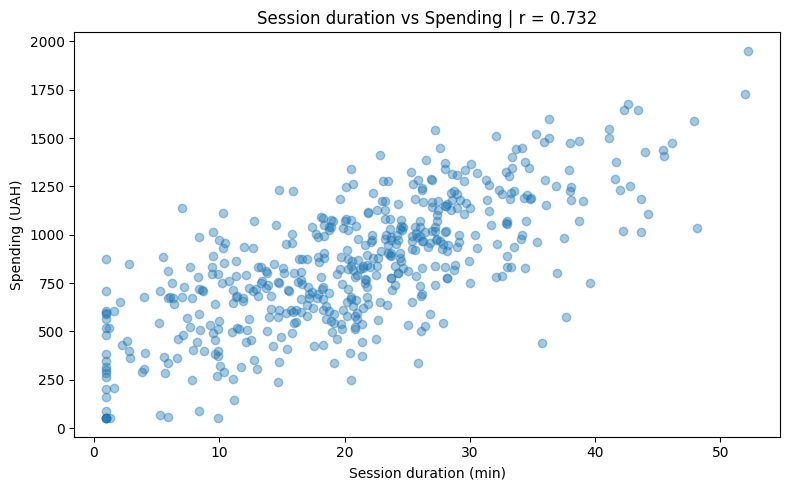

In [30]:
# Завдання 12:
r, p_value = stats.pearsonr(df["session_min"], df["spend"])
print(f"Correlation coefficient r: {r:.3f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("✅ Correlation is statistically significant")
else:
    print("❌ No significant correlation found")

plt.figure(figsize=(8, 5))
plt.scatter(df["session_min"], df["spend"], alpha=0.4)
plt.xlabel("Session duration (min)")
plt.ylabel("Spending (UAH)")
plt.title(f"Session duration vs Spending | r = {r:.3f}")
plt.tight_layout()
plt.show()

#### 💬 Інтерпретація 10

Опишіть звʼязок: він прямий чи зворотний? Сильний чи слабкий? Значущий? І найголовніше: чи можна стверджувати, що довший час на сайті СПРИЧИНЯЄ більші витрати? Поясніть свою думку.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

r = 0.732, p < 0.001 → statistically significant strong positive correlation.

Direction: POSITIVE (direct) — the longer the session, the higher the spending.
Strength: STRONG — r = 0.73 is well above the 0.5 threshold for strong correlation.
Significance: YES — p is virtually zero, this is not a coincidence.

Can we say that longer session CAUSES higher spending?
NO — correlation is not causation.

There are three possible explanations:
1. Longer session → more time to browse → more purchases (causation)
2. Higher purchase intent → user spends more time AND more money (reverse)
3. A third factor (e.g. high interest in the product) causes BOTH
   longer sessions AND higher spending simultaneously

To prove causation we would need an experiment —
for example A/B test where we force some users to stay longer
and measure if their spending actually increases.

Practical takeaway:
Session duration is a strong predictor of spending
and is worth tracking as a key business metric —
but artificially extending sessions will not necessarily
increase revenue without genuine user engagement.

**Сценарій:** чи повʼязаний вік клієнта (`age`) з його витратами (`spend`)?

#### ✏️ Завдання 13 (код)

Порахуйте кореляцію між `age` та `spend`.

In [31]:
# Завдання 13:
r, p_value = stats.pearsonr(df["age"], df["spend"])
print(f"Correlation coefficient r: {r:.3f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("✅ Correlation is statistically significant")
else:
    print("❌ No significant correlation found")

Correlation coefficient r: -0.042
p-value: 0.350752
❌ No significant correlation found


#### 💬 Інтерпретація 11

Що показала кореляція? Порівняйте цей результат із попереднім (час на сайті vs витрати). У якому випадку звʼязок сильніший і чому це важливо для бізнесу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Age vs Spending: r = -0.042, p = 0.35 → no significant correlation.
The relationship is virtually zero and could have occurred by chance.

Comparison with previous result:
Session duration vs Spending: r = 0.732 ✅ strong significant correlation
Age vs Spending:              r = -0.042 ❌ no correlation

Session duration is a much stronger predictor of spending than age.

What does r = -0.042 mean in practice?
The minus sign suggests a very slight tendency that older users
spend less — but it is so weak that we cannot rely on it.
Age simply does not predict how much a user will spend.

Business importance:
- Segmenting users by age for spending-based campaigns is pointless
- Focus should be on session duration instead —
  users who spend more time on the site are much more
  likely to spend more money
- Invest in features that increase engagement and session duration
  rather than age-targeted advertising
  

---
# Розділ 7. 🔥 Велике завдання: A/B-тест

## 🟦 Теорія: A/B-тестування

Це головне застосування статистики в аналітиці. Ми порівнюємо дві версії (A — контроль, B — варіант) і перевіряємо, чи нова версія справді краща, чи різниця випадкова.

Оскільки результат тут — **категоріальний** (конвертувався / ні), ми використовуємо **хі-квадрат** на таблиці спряженості «група × конверсія».

**Дані `ab_test.csv`:**
- `session_id` — ID сесії
- `group` — A (стара версія) або B (нова версія)
- `converted` — 1 (купив) або 0 (не купив)

Це повноцінне завдання, що імітує реальну роботу аналітика. Виконуйте крок за кроком.

**Крок 1. Дослідіть дані.**

#### ✏️ Завдання 14 (код)

Подивіться на дані `ab`: скільки сесій у групі A і скільки в групі B? (підказка: `value_counts` на `group`)

In [32]:
# Завдання 14:
print(ab["group"].value_counts())


group
A    4000
B    4000
Name: count, dtype: int64


**Крок 2. Порахуйте конверсію кожної групи.**

Конверсія = частка тих, хто купив = середнє значення стовпця `converted` (бо це 0 і 1).

#### ✏️ Завдання 15 (код)

Порахуйте конверсію (середнє `converted`) для групи A і для групи B окремо. (Підказка: `ab.groupby('group')['converted'].mean()`) На скільки відсоткових пунктів відрізняється конверсія?

In [39]:
# Завдання 15:
print(ab.groupby("group")["converted"].mean().round(4))

group
A    0.101
B    0.119
Name: converted, dtype: float64


#### 💬 Інтерпретація 12

Яка група показує вищу конверсію? Чи означає ця різниця в числах, що версія B точно краща? Чому ми НЕ можемо зробити висновок лише з цих чисел, без статистичного тесту?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Group B shows higher conversion — 11.9% vs 10.1%. The difference is 1.8 percentage points. Now we need a chi-square or z-test to check if this difference is statistically significant or just by chance.
Does this mean version B is definitely better?
NO — not without a statistical test.

Why we CANNOT conclude from numbers alone:

We have 4000 users in each group.
With such a sample, random fluctuations can easily
produce a 1-2% difference even if both versions are identical.  
Only a statistical test (chi-square or z-test) can tell us
whether this 1.8% difference is significant or could have
occurred by chance.

Without a test — any business decision based on these
numbers alone would be a gamble.

**Крок 3. Сформулюйте гіпотези.**

#### 💬 Інтерпретація 13

Запишіть нульову (H₀) та альтернативну (H₁) гіпотези для цього A/B-тесту своїми словами.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

H₀ (Null hypothesis):
There is no difference in conversion between version A and version B.
Any observed difference is due to random chance.
Conversion A = Conversion B

H₁ (Alternative hypothesis):
Version B has a higher conversion rate than version A.
The difference is real and not due to random chance.
Conversion B > Conversion A

In numbers:
H₀: 11.9% - 10.1% = 0 (just noise)
H₁: 11.9% - 10.1% = real effect

We reject H₀ only if p-value < 0.05.

**Крок 4. Проведіть тест.**

#### ✏️ Завдання 16 (код)

Побудуйте таблицю спряженості `group` × `converted` і проведіть тест хі-квадрат. Виведіть таблицю та p-значення.

In [41]:
# Завдання 16:
contingency = pd.crosstab(ab["group"], ab["converted"])
print("Contingency table:")
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2:    {chi2:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Significant difference between groups")
else:
    print("❌ No significant difference found")

Contingency table:
converted     0    1
group               
A          3596  404
B          3524  476

chi2:    6.436
p-value: 0.0112
✅ Significant difference between groups


**Крок 5. Висновок.**

#### 💬 Інтерпретація 14

На основі p-значення: чи є різниця між версіями статистично значущою (при α = 0.05)? Який ваш висновок — впроваджувати версію B чи ні? Сформулюйте фінальну рекомендацію для продуктової команди одним абзацом, як справжній аналітик.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

chi2 = 6.436, p = 0.0112 (< 0.05) → we reject H₀.
The difference in conversion between versions A and B
is statistically significant.

Group A: 404/4000 = 10.1% conversion
Group B: 476/4000 = 11.9% conversion
Difference: +1.8 percentage points

Final recommendation for the product team:
The data provides sufficient statistical evidence to recommend
rolling out version B to all users. With 4000 users per group
and p = 0.011, the probability that this result occurred by chance
is only 1.1% — well below our 5% threshold. Version B generates
approximately 18% more conversions relative to version A
(from 10.1% to 11.9%), which at scale translates to a meaningful
increase in revenue. I recommend proceeding with version B
while continuing to monitor conversion rates post-launch
to confirm the effect holds on the full user base.


---
# Розділ 8. 🧠 Обери тест сам

## 🟦 Теорія

Найважливіша навичка аналітика — не запам'ятати функції, а вміти **обрати правильний тест** для задачі. У цьому розділі ми НЕ підказуємо тест — ви маєте визначити його самі.

**Алгоритм вибору:**
1. Який тип даних на виході? (числовий чи категоріальний)
2. Скільки груп / змінних порівнюємо?
3. Це незалежні групи чи «до/після» в тих самих об'єктів?

Кожне завдання: спочатку у клітинці інтерпретації **назвіть тест і поясніть вибір**, потім напишіть код.

**Задача A.** Компанія хоче знати, чи відрізняється середній вік клієнтів у трьох каналах залучення.

#### 💬 Інтерпретація 15

Який тест ви оберете і чому? (Спочатку відповідь, потім код нижче.)

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Test choice: ONE-WAY ANOVA (stats.f_oneway)

Why:
1. Output type: NUMERICAL (age)
2. Number of groups: THREE (organic, advertising, social media)
3. Independent groups: YES (different customers in each channel)

These three criteria point directly to ANOVA.
If there were 2 groups → t-test.
If the data were categorical → chi-square.
If it were before/after → paired t-test.

#### ✏️ Завдання 17 (код)

Проведіть обраний тест для задачі A (вік за каналами).

In [44]:
# Завдання 17:
for channel in df["channel"].unique():
    avg = df[df["channel"] == channel]["age"].mean()
    print(f"{channel}: {avg:.1f} years")

groups = [df[df["channel"] == ch]["age"] for ch in df["channel"].unique()]

f_stat, p_value = stats.f_oneway(*groups)
print(f"\nF-statistic: {f_stat:.3f}")
print(f"p-value:     {p_value:.4f}")

if p_value < 0.05:
    print("✅ At least one channel differs significantly in age")
else:
    print("❌ No significant difference in age between channels")


Реклама: 35.4 years
Органіка: 34.4 years
Соцмережі: 34.2 years

F-statistic: 0.599
p-value:     0.5498
❌ No significant difference in age between channels


#### 💬 Інтерпретація 16

Що показав результат? Сформулюйте висновок.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Advertising: 35.4, Organic: 34.4, Social Media: 34.2 years
F-statistic = 0.599, p = 0.55 (> 0.05) → we do not reject H₀.

No significant difference in average age between channels was found.

All three channels attract customers of virtually the same age
(34-35 years). The difference of about 1 year could have
occurred by chance.

Practical meaning:
Age-based audience segmentation by channel is not justified.
All three channels reach the same age demographic.
There is no reason to create age-targeted content
specifically for one channel over another.

**Задача B.** Маркетолог стверджує, що середні витрати клієнтів дорівнюють 900 грн.

#### 💬 Інтерпретація 17

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Test choice: ONE-SAMPLE T-TEST (stats.ttest_1samp)

Why:
1. Output type: NUMERICAL (spend)
2. Number of groups: ONE — we compare our sample against a fixed number (900)
3. Independent groups: not applicable — we have one group vs a constant

We are not comparing two groups against each other.
We are checking whether OUR data differs from a specific claimed value.
This is exactly what a one-sample t-test is designed for.

H₀: average spend = 900 UAH
H₁: average spend ≠ 900 UAH

#### ✏️ Завдання 18 (код)

Проведіть обраний тест для задачі B.

In [45]:
# Завдання 18:
print(f"Actual average spend: {df['spend'].mean():.1f} UAH")

t_stat, p_value = stats.ttest_1samp(df["spend"], 900)
print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value:.4f}")

if p_value < 0.05:
    print("✅ Significant difference from 900 UAH")
else:
    print("❌ No significant difference from 900 UAH")

Actual average spend: 845.0 UAH

t-statistic: -3.687
p-value:     0.0003
✅ Significant difference from 900 UAH


#### 💬 Інтерпретація 18

Висновок: маркетолог має рацію?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Actual average spend = 845 UAH (not 900 UAH)
t-statistic = -3.687, p = 0.0003 (< 0.05) → we reject H₀.

The marketer is WRONG.

The difference of 55 UAH is statistically significant —
the probability that this occurred by chance is only 0.03%.

The negative t-statistic confirms that the actual average
is BELOW 900 UAH, not above it.

Recommendation:
The marketing team should update their assumptions.
The realistic average customer spend is around 845 UAH,
not 900 UAH. Any budget planning or revenue forecasting
based on 900 UAH will be systematically overestimated.


**Задача C.** Чи повʼязана країна клієнта (`country`) з пристроєм (`device`)?

#### 💬 Інтерпретація 19

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Test choice: CHI-SQUARE TEST (stats.chi2_contingency)

Why:
1. Output type: CATEGORICAL (country and device — both are categories)
2. Number of groups: TWO categorical variables
3. Independent groups: YES — different customers

When we want to check if two categorical variables
are associated with each other → chi-square test.

H₀: country and device are independent (no association)
H₁: country and device are associated

Contingency table: country × device

#### ✏️ Завдання 19 (код)

Проведіть обраний тест для задачі C.

In [46]:
# Завдання 19:
contingency = pd.crosstab(df["country"], df["device"])
print("Contingency table:")
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nchi2:    {chi2:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Country IS associated with device type")
else:
    print("❌ No association between country and device found")

Contingency table:
device     Desktop  Mobile
country                   
Німеччина       46      63
Польща          49      82
Україна         94     166

chi2:    1.207
p-value: 0.5470
❌ No association between country and device found


#### 💬 Інтерпретація 20

Висновок про звʼязок країни та пристрою.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

chi2 = 1.207, p = 0.55 (> 0.05) → we do not reject H₀.
No significant association between country and device was found.

Looking at the contingency table:
- Germany:  42% Desktop / 58% Mobile
- Poland:   37% Desktop / 63% Mobile
- Ukraine:  36% Desktop / 64% Mobile

All three countries show very similar device usage patterns —
roughly 37-42% Desktop and 58-64% Mobile.

Practical meaning:  
Country does not influence device preference.
There is no reason to create country-specific
mobile or desktop experiences.
All three markets behave the same way in terms of device usage.

**Задача D.** Чи повʼязаний вік клієнта з часом, який він проводить на сайті?

#### 💬 Інтерпретація 21

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

Test choice: PEARSON CORRELATION (stats.pearsonr)

Why:
1. Output type: NUMERICAL — both age and session_min are numbers
2. Number of variables: TWO continuous variables
3. Goal: check if there is a LINEAR relationship between them

When we want to measure the strength and direction
of a relationship between two numerical variables
→ Pearson correlation.  
Chi-square → categorical vs categorical
T-test / ANOVA → numerical vs categorical (groups)
Pearson → numerical vs numerical ✅

H₀: there is no correlation between age and session duration (r = 0)
H₁: there is a significant correlation (r ≠ 0)


#### ✏️ Завдання 20 (код)

Проведіть обраний тест для задачі D.

In [38]:
# Завдання 20:


#### 💬 Інтерпретація 22

Опишіть звʼязок (напрямок, сила, значущість).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*...*

---
# 🎉 Вітаємо із завершенням!

Ви пройшли повний цикл роботи аналітика зі статистичними тестами:

- ✅ Одновибірковий, двовибірковий та парний t-тести
- ✅ ANOVA для 3+ груп
- ✅ Хі-квадрат для категоріальних даних
- ✅ Кореляція для числових змінних
- ✅ Повноцінний A/B-тест
- ✅ Самостійний вибір тесту під задачу

## Головне, що варто винести

1. **Вибір тесту** важливіший за код. Завжди питайте: який тип даних? скільки груп? незалежні чи парні?
2. **p-значення** саме по собі — це лише число. Цінність створює ваша **інтерпретація**.
3. **Контекст вирішує:** памʼятайте про розмір ефекту, практичну значущість і те, що кореляція ≠ причинність.

## Питання для самоперевірки
- Чи можете ви пояснити різницю між парним і двовибірковим t-тестом?
- Чому не можна замінити одну ANOVA трьома t-тестами?
- Що означає «не відхилили H₀» — чи це те саме, що «довели, що ефекту немає»?

Якщо на всі три питання ви відповідаєте впевнено — ви добре засвоїли тему. Так тримати! 📊
